# Spectrum of the preconditioned Hessian misfit operator
## The linear source inversion problem

We consider the following linear source inversion problem. Find the state
$u \in H^1_{\Gamma_D}(\Omega)$ and the source (*parameter*) $m \in H^1(\Omega)$ that solves

$$
\begin{aligned}
& \min_m \frac{1}{2\sigma^2} \| Bu - u_d \|^2 + \frac{1}{2} \int_\Omega \left[ \delta|m-m_0|^2 + \gamma|\nabla (m - m_0)|^2 \right] dx \\
& \text{s.t.} \\
& -{\rm div}(k \nabla u) + {\bf v}\cdot \nabla u + cu = m \quad {\rm in} \; \Omega,\\
& u = 0 \quad {\rm on } \; \Gamma_D,\\
& k \frac{\partial u}{\partial n} = 0 \quad {\rm on } \; \Gamma_N.
\end{aligned}
$$

Here:

- $u_d$ is an $n_{\rm obs}$ finite dimensional vector that denotes noisy observations of the state $u$ in $n_{\rm obs}$ locations $\{ {\bf x}_i\}_{i=1}^{n_{\rm obs}}$. Specifically, $u_d(i) = u_{\rm true}( {\bf x}_i ) + \eta_i$, where $\eta_i$ are i.i.d. $\mathcal{N}(0, \sigma^2)$.
- $B: H^1_0(\Omega) \rightarrow \mathbb{R}^{n_{\rm obs}}$ is the linear operator that evaluates the state $u$ at the observation locations $\{ {\bf x}_i\}_{i=1}^{n_{\rm obs}}$.
- $\delta$ and $\gamma$ are the parameters of the regularization penalizing the $L^2(\Omega)$ and $H^1(\Omega)$ norm of $m-m_0$, respectively.
- $k$, ${\bf v}$, $c$ are given coefficients representing the diffusivity coefficient, the advective velocity and the reaction term, respectively.
- $\Gamma_D \subset \partial \Omega$, $\Gamma_N \subset \partial \Omega$ represents the subdomain of $\partial\Omega$ where we impose Dirichlet or Neumann boundary conditions, respectively.

Because the problem is linear, the Hessian does not depend on $m$, and its spectrum, and
what it depends on, can be studied on its own: the mesh, the noise, and the coefficients
of the PDE.

## 1. Load modules

In [1]:
import os
import sys

sys.path.insert(0, os.environ.get("HIPPYMFEM_BASE_DIR", os.path.abspath("..")))

import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from mpi4py import MPI
import mfem.par as mfem

import hippymfem as hm
from hippymfem import nb, STATE, PARAMETER, ADJOINT

import jax.numpy as jnp

mfem.Hypre.Init()
comm = MPI.COMM_WORLD

## 2. The linear source inversion problem

`solve` sets up and solves the inverse problem on an `nx` by `ny` mesh, and returns the
generalized eigenvalues and eigenvectors of the Hessian misfit together with the number of
CG iterations the (exact) Newton solve took. The coefficients $k$, ${\bf v}$ and $c$ are
arguments, and the residual density is defined inside `solve`, so each call differentiates
the problem it was given.

In [2]:
def solve(nx, ny, targets, rel_noise, gamma, delta, k=1.0, v=(0.0, 0.0), c=0.0, verbose=True):
    mesh = mfem.ParMesh(comm, mfem.Mesh.MakeCartesian2D(nx, ny, mfem.Element.TRIANGLE))
    Vh1 = hm.FunctionSpace.H1(mesh, 1)
    Vh = [Vh1, Vh1, Vh1]
    if verbose:
        print("Number of dofs: STATE={0}, PARAMETER={1}, ADJOINT={2}".format(
            Vh[STATE].GlobalTrueVSize(), Vh[PARAMETER].GlobalTrueVSize(), Vh[ADJOINT].GlobalTrueVSize()))

    velocity = jnp.asarray(v)

    def pde_varf(u, m, p, x):
        return (k * hm.inner(u.grad, p.grad) + jnp.dot(velocity, u.grad) * p.val
                + c * u.val * p.val - m.val * p.val)

    bottom = 1                                   # u = 0 on y = 0, insulated elsewhere
    bc = hm.DirichletBC(Vh[STATE], 0.0, bdr_attributes=[bottom])
    bc0 = bc.homogeneous()

    mtrue = Vh[PARAMETER].project(
        lambda x: min(0.5, math.exp(-100.0 * ((x[0] - 0.35) ** 2 + (x[1] - 0.7) ** 2))))
    m0 = Vh[PARAMETER].vector()

    pde = hm.PDEVariationalProblem(Vh, pde_varf, bc, bc0, is_fwd_linear=True)

    if verbose:
        print("Number of observation points: {0}".format(targets.shape[0]))

    B = hm.assemblePointwiseObservation(Vh[STATE], targets)

    reg = hm.LaplacianPrior(Vh[PARAMETER], gamma, delta)

    # generate synthetic observations
    utrue = pde.generate_state()
    x = [utrue, mtrue, None]
    pde.solveFwd(x[STATE], x)
    data = B.createVecLeft()
    B.mult(x[STATE], data)
    MAX = data.norm("linf")
    noise_std_dev = rel_noise * MAX
    hm.parRandom.set_seed(1)
    B.perturb(data, noise_std_dev)
    misfit = hm.DiscreteStateObservation(B, data, noise_std_dev ** 2)

    if verbose:
        plt.figure(figsize=(18, 4))
        nb.plot(Vh[PARAMETER], mtrue, mytitle="True source", subplot_loc=131)
        nb.plot(Vh[STATE], utrue, mytitle="True state", subplot_loc=132)
        nb.plot_pts(targets, B.gather(data), mytitle="Observations", subplot_loc=133)
        plt.show()

    model = hm.Model(pde, reg, misfit)
    u = model.generate_vector(STATE)
    m = m0.copy()
    p = model.generate_vector(ADJOINT)
    x = [u, m, p]
    mg = model.generate_vector(PARAMETER)
    model.solveFwd(u, x)
    model.solveAdj(p, x)
    model.evalGradientParameter(x, mg)
    model.setPointForHessianEvaluations(x, gauss_newton_approx=False)

    H = hm.ReducedHessian(model)

    solver = hm.CGSolverSteihaug(hm.CGSolverSteihaug_ParameterList(), comm)
    solver.set_operator(H)
    solver.set_preconditioner(reg.Rsolver)
    solver.parameters["print_level"] = -1
    solver.parameters["rel_tolerance"] = 1e-9
    solver.solve(m, -mg)

    if not solver.converged:
        raise RuntimeError("CG did not converge")
    if verbose:
        print("CG converged in", solver.iter, "iterations.")

    model.solveFwd(u, x)
    total_cost, reg_cost, misfit_cost = model.cost(x)

    if verbose:
        residual = B.createVecLeft()
        B.mult(u, residual)
        residual.axpy(-1.0, data)
        plt.figure(figsize=(18, 4))
        nb.plot(Vh[PARAMETER], m, mytitle="Reconstructed source", subplot_loc=131)
        nb.plot(Vh[STATE], u, mytitle="Reconstructed state", subplot_loc=132)
        nb.plot_pts(targets, B.gather(residual), mytitle="Misfit", subplot_loc=133)
        plt.show()

    H.misfit_only = True
    k_evec = 80
    p_evec = 5
    if verbose:
        print("Double Pass Algorithm. Requested eigenvectors: {0}; Oversampling {1}.".format(k_evec, p_evec))
    Omega = hm.MultiVector(x[PARAMETER], k_evec + p_evec)
    hm.parRandom.normal_multivector(1.0, Omega)
    lmbda, V = hm.doublePassG(H, reg.R, reg.Rsolver, Omega, k_evec)

    if verbose:
        plt.figure()
        nb.plot_eigenvalues(lmbda, mytitle="Generalized Eigenvalues")
        nb.plot_eigenvectors(Vh[PARAMETER], V, mytitle="Eigenvectors", which=[0, 1, 2, 5, 10, 15])
        plt.show()

    return lmbda, V, Vh[PARAMETER], solver.iter

## 3. Solution of the source inversion problem

Number of dofs: STATE=1089, PARAMETER=1089, ADJOINT=1089
Number of observation points: 300


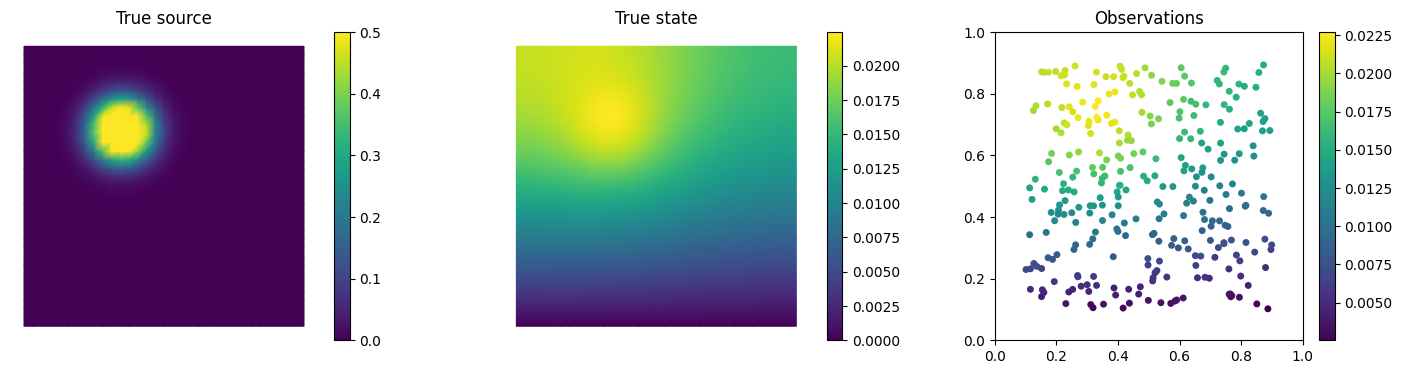

CG converged in 95 iterations.


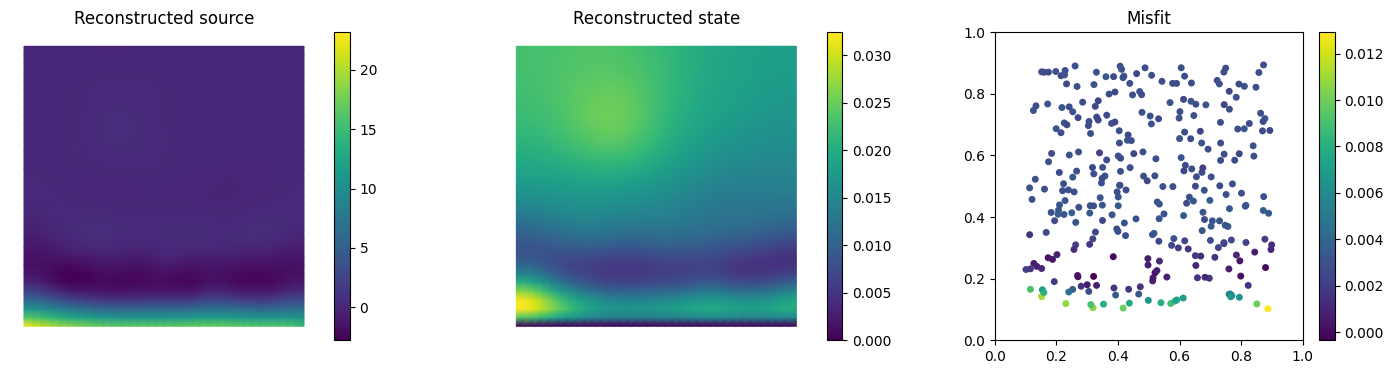

Double Pass Algorithm. Requested eigenvectors: 80; Oversampling 5.


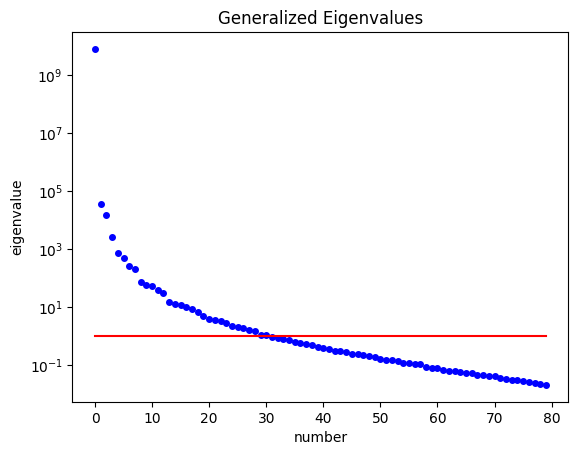

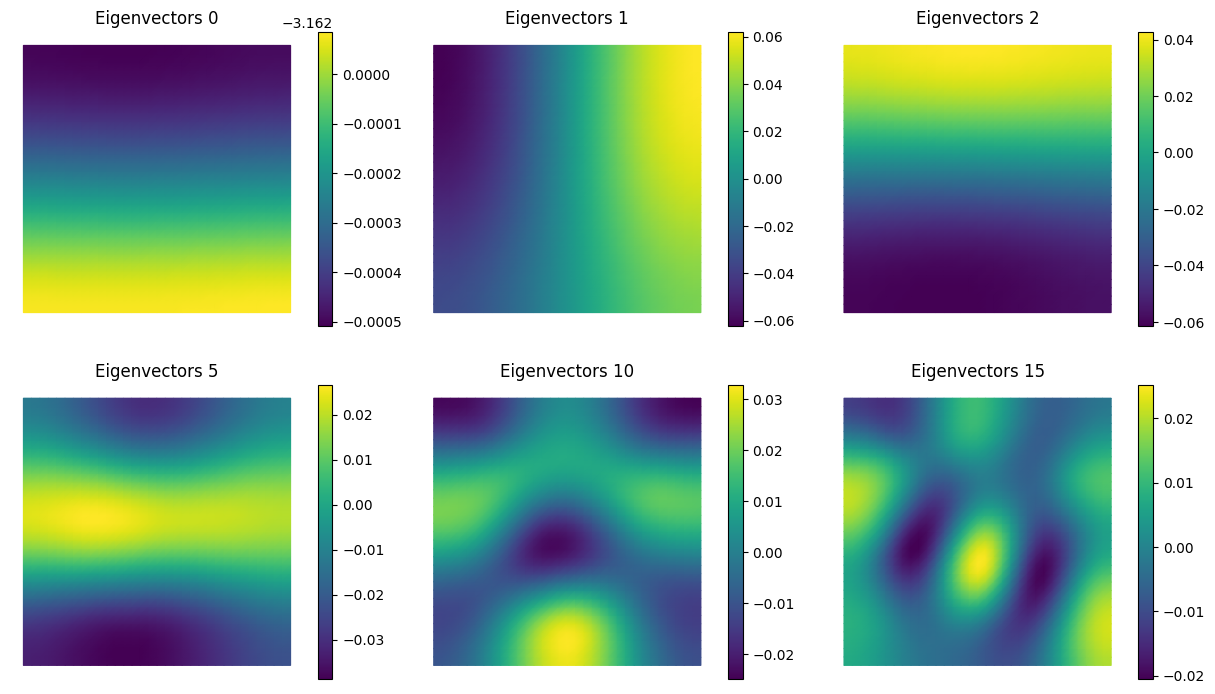

In [3]:
ndim = 2
nx = 32
ny = 32

ntargets = 300
rng = np.random.default_rng(1)
targets = rng.uniform(0.1, 0.9, [ntargets, ndim])
rel_noise = 0.01

gamma = 70.0
delta = 1e-1

lmbda, V, Vm, nit = solve(nx, ny, targets, rel_noise, gamma, delta)

## 4. Mesh independence of the spectrum of the preconditioned Hessian misfit

The spectrum, and with it the number of CG iterations, does not grow as the mesh is
refined: the data inform the same directions whatever the discretization.

Number of Iterations:  96 95 82


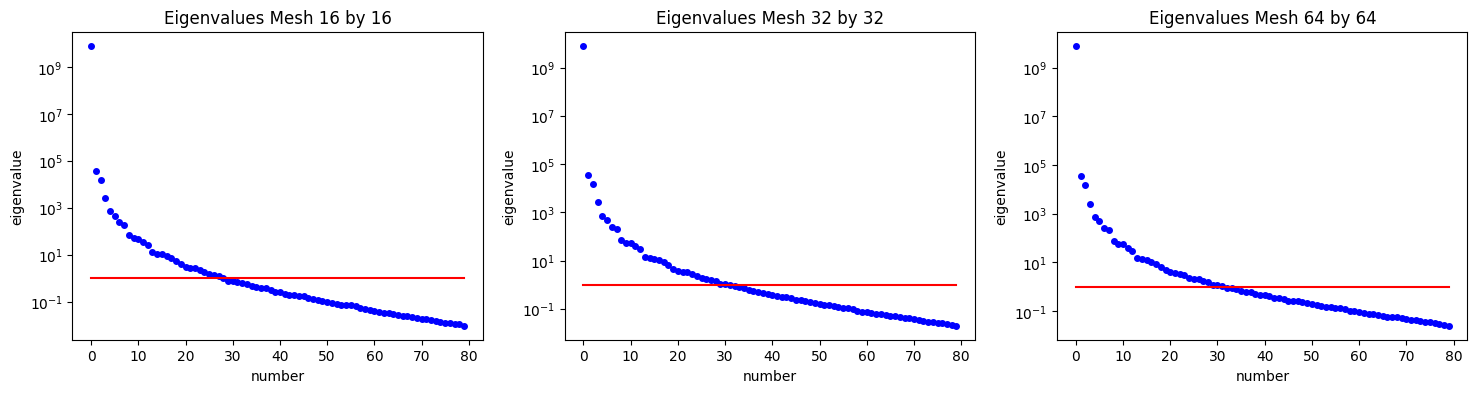

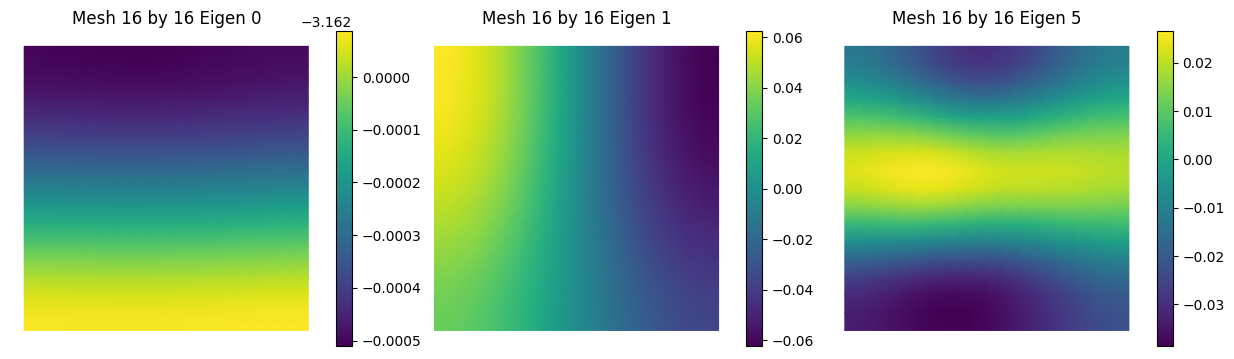

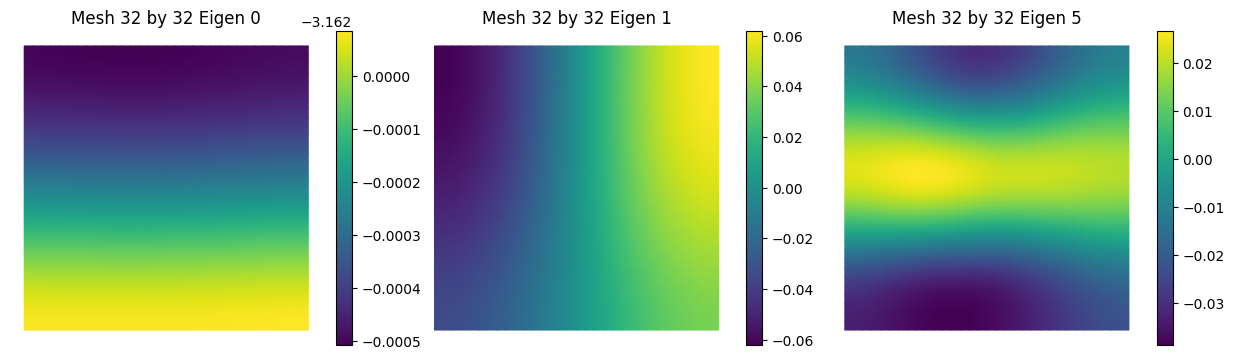

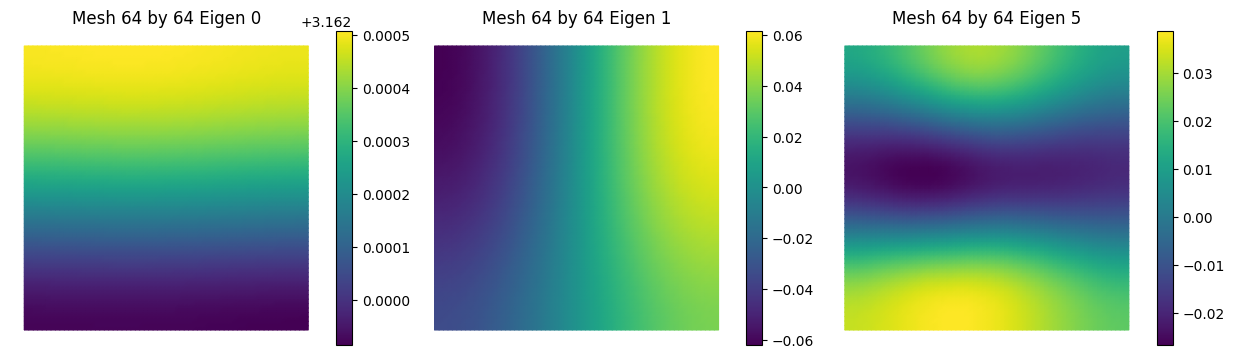

In [4]:
gamma = 70.0
delta = 1e-1

n = [16, 32, 64]
lmbda1, V1, Vm1, niter1 = solve(n[0], n[0], targets, rel_noise, gamma, delta, verbose=False)
lmbda2, V2, Vm2, niter2 = solve(n[1], n[1], targets, rel_noise, gamma, delta, verbose=False)
lmbda3, V3, Vm3, niter3 = solve(n[2], n[2], targets, rel_noise, gamma, delta, verbose=False)

print("Number of Iterations: ", niter1, niter2, niter3)
plt.figure(figsize=(18, 4))
nb.plot_eigenvalues(lmbda1, mytitle="Eigenvalues Mesh {0} by {1}".format(n[0], n[0]), subplot_loc=131)
nb.plot_eigenvalues(lmbda2, mytitle="Eigenvalues Mesh {0} by {1}".format(n[1], n[1]), subplot_loc=132)
nb.plot_eigenvalues(lmbda3, mytitle="Eigenvalues Mesh {0} by {1}".format(n[2], n[2]), subplot_loc=133)

nb.plot_eigenvectors(Vm1, V1, mytitle="Mesh {0} by {1} Eigen".format(n[0], n[0]), which=[0, 1, 5])
nb.plot_eigenvectors(Vm2, V2, mytitle="Mesh {0} by {1} Eigen".format(n[1], n[1]), which=[0, 1, 5])
nb.plot_eigenvectors(Vm3, V3, mytitle="Mesh {0} by {1} Eigen".format(n[2], n[2]), which=[0, 1, 5])

plt.show()

## 5. Dependence on the noise level

We solve the problem for different noise levels. The higher the noise level the more
important becomes the effect of the regularization.

Number of Iterations:  556 95 21


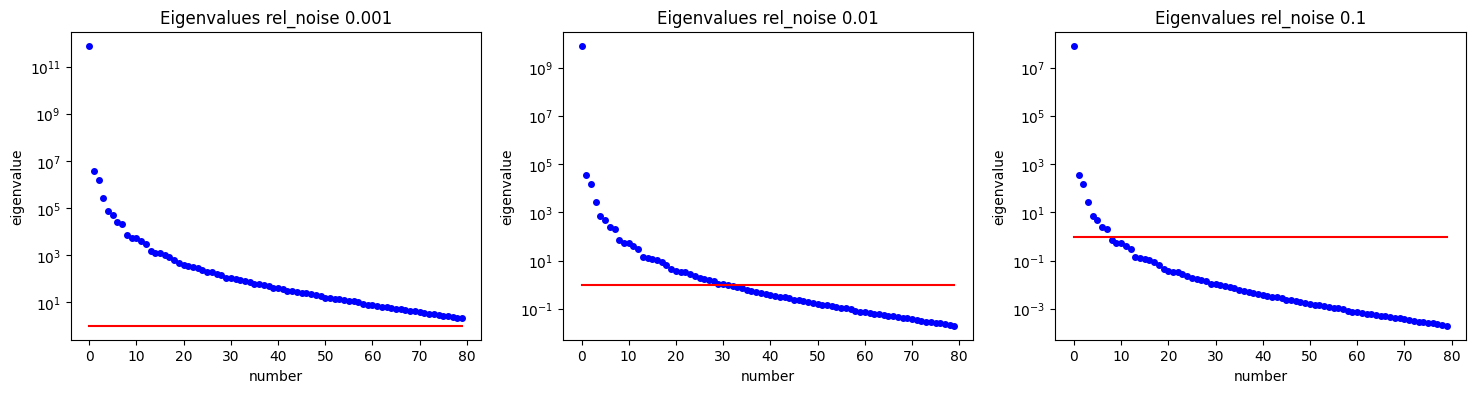

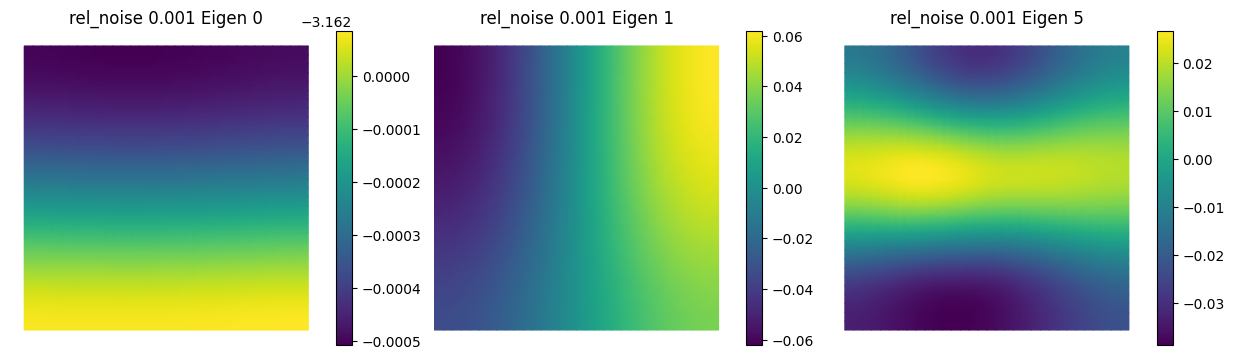

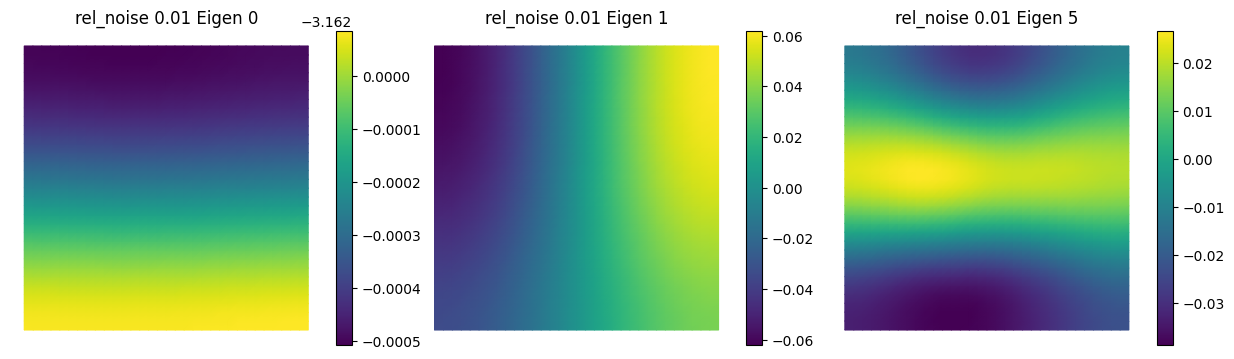

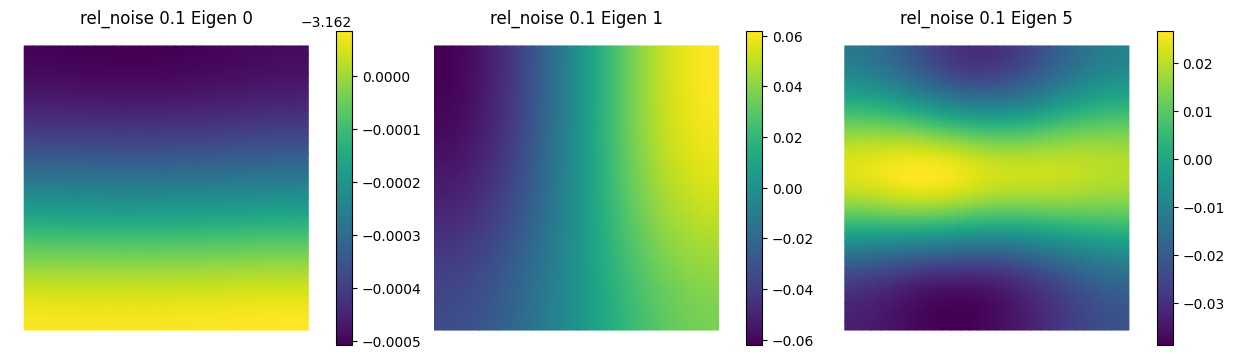

In [5]:
gamma = 70.0
delta = 1e-1

rel_noise = [1e-3, 1e-2, 1e-1]
lmbda1, V1, Vm1, niter1 = solve(nx, ny, targets, rel_noise[0], gamma, delta, verbose=False)
lmbda2, V2, Vm2, niter2 = solve(nx, ny, targets, rel_noise[1], gamma, delta, verbose=False)
lmbda3, V3, Vm3, niter3 = solve(nx, ny, targets, rel_noise[2], gamma, delta, verbose=False)

print("Number of Iterations: ", niter1, niter2, niter3)
plt.figure(figsize=(18, 4))
nb.plot_eigenvalues(lmbda1, mytitle="Eigenvalues rel_noise {0:g}".format(rel_noise[0]), subplot_loc=131)
nb.plot_eigenvalues(lmbda2, mytitle="Eigenvalues rel_noise {0:g}".format(rel_noise[1]), subplot_loc=132)
nb.plot_eigenvalues(lmbda3, mytitle="Eigenvalues rel_noise {0:g}".format(rel_noise[2]), subplot_loc=133)

nb.plot_eigenvectors(Vm1, V1, mytitle="rel_noise {0:g} Eigen".format(rel_noise[0]), which=[0, 1, 5])
nb.plot_eigenvectors(Vm2, V2, mytitle="rel_noise {0:g} Eigen".format(rel_noise[1]), which=[0, 1, 5])
nb.plot_eigenvectors(Vm3, V3, mytitle="rel_noise {0:g} Eigen".format(rel_noise[2]), which=[0, 1, 5])

plt.show()

## 6. Dependence on the PDE coefficients

Assume a constant reaction term $c = 1$, and consider different values for the
diffusivity coefficient $k$.

The smaller the value of $k$ the slower the decay in the spectrum.

Number of Iterations:  106 178 261


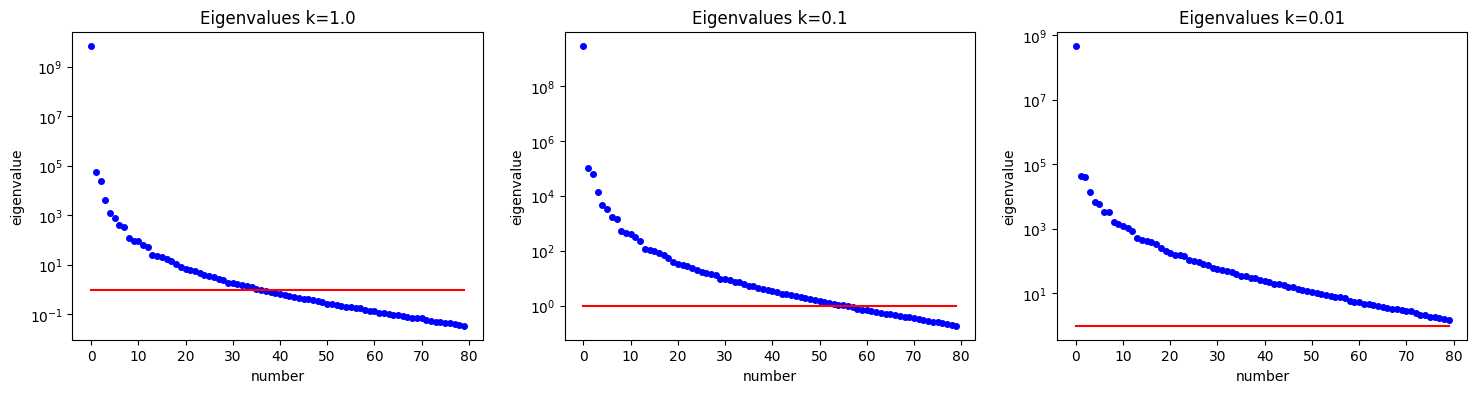

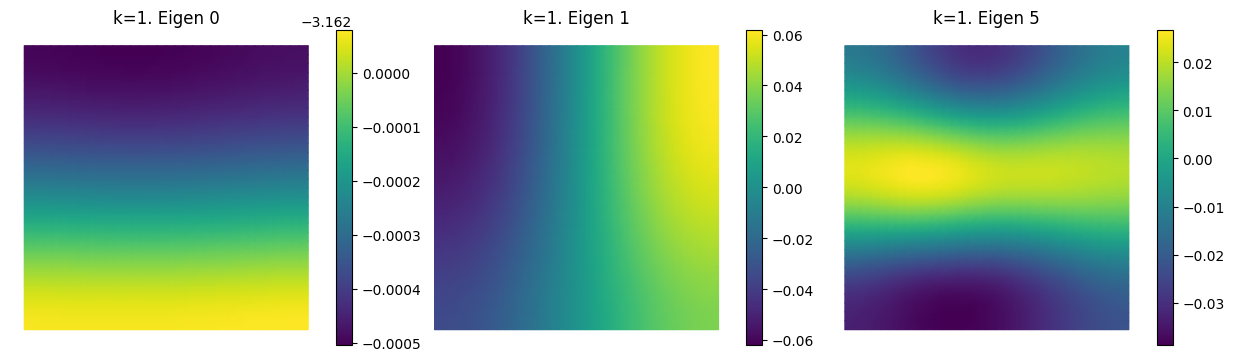

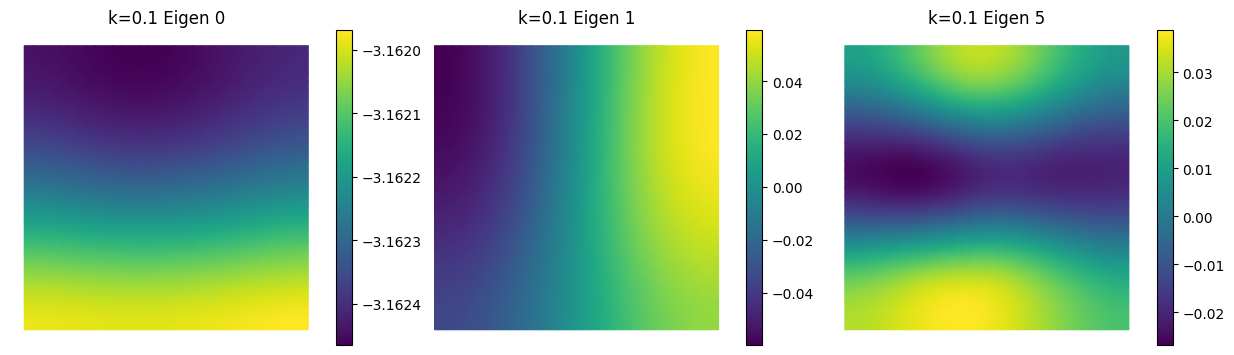

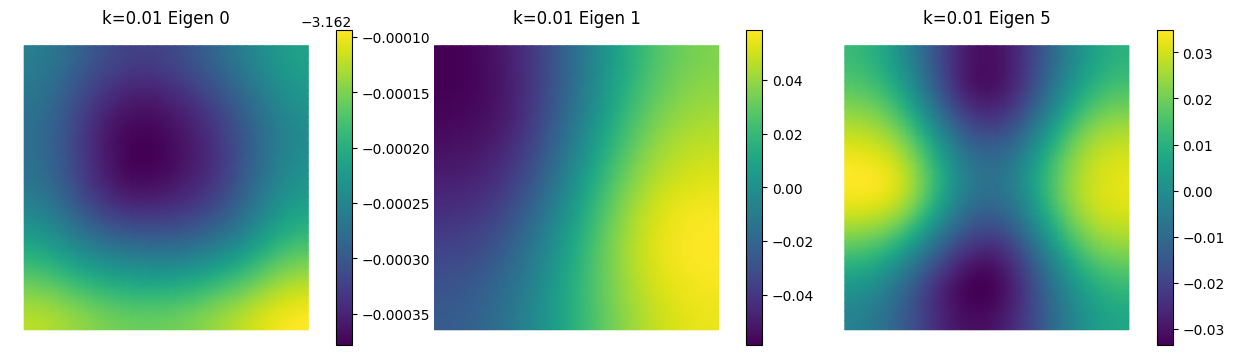

In [6]:
rel_noise = 0.01

lmbda1, V1, Vm1, niter1 = solve(nx, ny, targets, rel_noise, gamma, delta, k=1.0, c=1.0, verbose=False)
lmbda2, V2, Vm2, niter2 = solve(nx, ny, targets, rel_noise, gamma, delta, k=0.1, c=1.0, verbose=False)
lmbda3, V3, Vm3, niter3 = solve(nx, ny, targets, rel_noise, gamma, delta, k=0.01, c=1.0, verbose=False)

print("Number of Iterations: ", niter1, niter2, niter3)
plt.figure(figsize=(18, 4))
nb.plot_eigenvalues(lmbda1, mytitle="Eigenvalues k=1.0", subplot_loc=131)
nb.plot_eigenvalues(lmbda2, mytitle="Eigenvalues k=0.1", subplot_loc=132)
nb.plot_eigenvalues(lmbda3, mytitle="Eigenvalues k=0.01", subplot_loc=133)

nb.plot_eigenvectors(Vm1, V1, mytitle="k=1. Eigen", which=[0, 1, 5])
nb.plot_eigenvectors(Vm2, V2, mytitle="k=0.1 Eigen", which=[0, 1, 5])
nb.plot_eigenvectors(Vm3, V3, mytitle="k=0.01 Eigen", which=[0, 1, 5])

plt.show()

*Adapted for hIPPyMFEM from hIPPYlib's tutorial `05_HessianSpectrum`.*

Copyright (c) 2016-2018, The University of Texas at Austin & University of California, Merced.<br>
Copyright (c) 2019-2022, The University of Texas at Austin, University of California--Merced, Washington University in St. Louis.<br>
Copyright (c) 2023-, The University of Texas at Austin, University of California--Merced.<br>
Copyright (c) 2026, Peng Chen, Georgia Institute of Technology.<br>
See file COPYRIGHT for details.

This file is part of hIPPyMFEM, free software under the GNU General Public License
version 2.0 dated June 1991 (GPL-2.0-only). hIPPyMFEM follows the programming model
of [hIPPYlib](https://hippylib.github.io).